In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/bank-additional.csv", sep=";")

In [4]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [6]:
# Vérification de la structure, des types de variables et de la présence de valeurs manquantes
#Le jeu de données contient 4 119 observations et 21 variables. 
#Aucune valeur manquante n'est détectée.
#les valeurs "unknown" seront néanmoins vérifiées séparément
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [7]:
# Vérification du nombre de valeurs "unknown" par variable
#nous avons un nombre important de modalités "unknown" concernant 4 variable
(df == "unknown").sum()

age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64

In [8]:
# ici, on cherche à connaitre la répartition de la variable cible selon les modalités de default
pd.crosstab(df["default"], df["y"], normalize="index") * 100

y,no,yes
default,,
no,87.873303,12.126697
unknown,93.897883,6.102117
yes,100.000000,0.000000


In [9]:
# Pourcentage de valeurs "unknown" par variable
unknown_pct = (df == "unknown").mean() * 100
unknown_pct[unknown_pct > 0].sort_values(ascending=False)

default      19.495023
education     4.054382
housing       2.549162
loan          2.549162
job           0.946832
marital       0.267055
dtype: float64

In [10]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

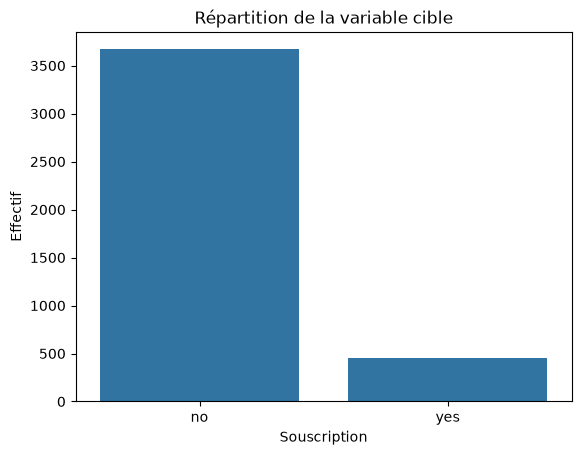

In [11]:
# Distribution de la variable cible
#La variable cible y présente un déséquilibre important entre ses deux modalités. La modalité no est largement majoritaire avec 3 668 observations, soit environ 89,1 % de l'échantillon, tandis que la modalité yes ne représente que 451 observations, soit environ 10,9 %. La population étudiée est donc majoritairement constituée d'individus n'ayant pas souscrit à l'offre. Ce déséquilibre devra être pris en compte lors de la modélisation et de l'évaluation des performances du modèle.
sns.countplot(data=df, x="y")
plt.title("Répartition de la variable cible")
plt.xlabel("Souscription")
plt.ylabel("Effectif")
plt.show()

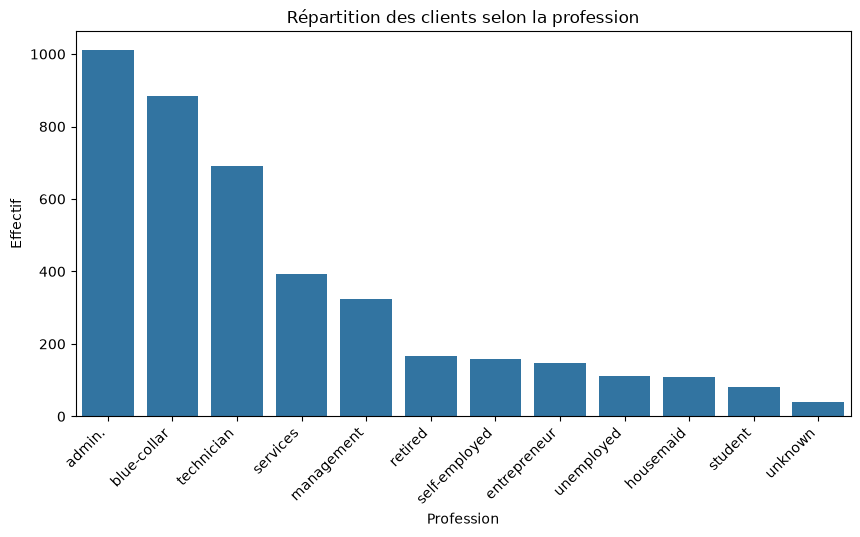

In [12]:
# Répartition des clients selon la profession
#Observation : La population est principalement composée de travailleurs et de personnes appartenant aux catégories de professions de bureau (`white_collar`). À l’inverse, les travailleurs indépendants (`self_employed`), les personnes inactives (`inactive`), les chômeurs (`unemployed`) et les autres profils (`other`) sont moins représentés. La population étudiée s’organise donc principalement autour de deux grands ensembles socioprofessionnels.
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="job", order=df["job"].value_counts().index)
plt.title("Répartition des clients selon la profession")
plt.xlabel("Profession")
plt.ylabel("Effectif")
plt.xticks(rotation=45, ha="right")
plt.show()

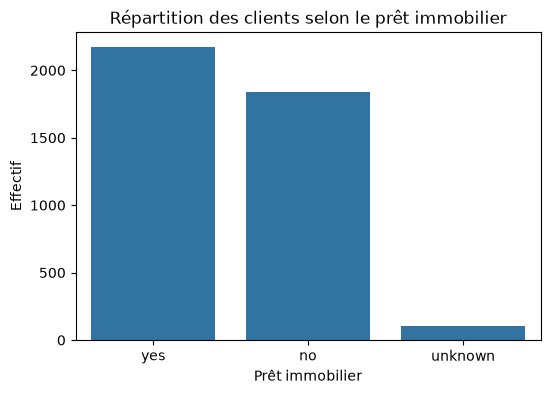

In [13]:
# Répartition des clients selon le prêt immobilier
#Les clients ayant un prêt immobilier sont légèrement plus nombreux que ceux n'en ayant pas. Les deux catégories restent toutefois bien représentées dans la population.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="housing", order=df["housing"].value_counts().index)
plt.title("Répartition des clients selon le prêt immobilier")
plt.xlabel("Prêt immobilier")
plt.ylabel("Effectif")
plt.show()

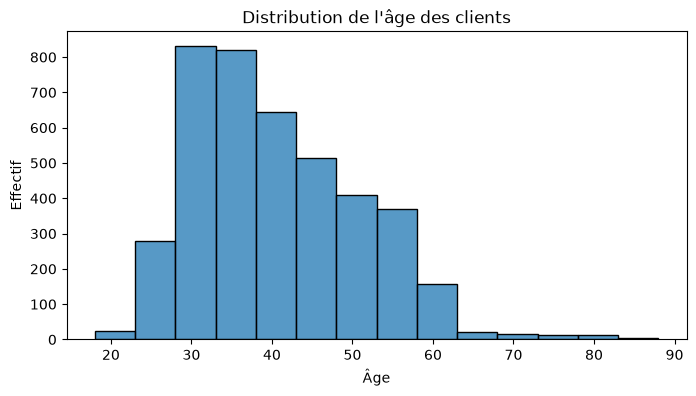

In [14]:
# Distribution de l'âge des clients
#La population est principalement concentrée entre 30 et 50 ans. Les individus les plus jeunes et les plus âgés sont moins représentés. Cette distribution permettra ensuite de justifier la création de classes d'âge pour certaines analyses.
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="age", binwidth=5)
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Effectif")
plt.show()

In [15]:
# Proportion de souscription selon la profession
job_y_pct = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

job_y_pct

y,no,yes
job,,
admin.,86.857708,13.142292
blue-collar,93.099548,6.900452
entrepreneur,94.594595,5.405405
housemaid,90.000000,10.000000
management,90.740741,9.259259
retired,77.108434,22.891566
self-employed,91.823899,8.176101
services,91.094148,8.905852
student,76.829268,23.170732


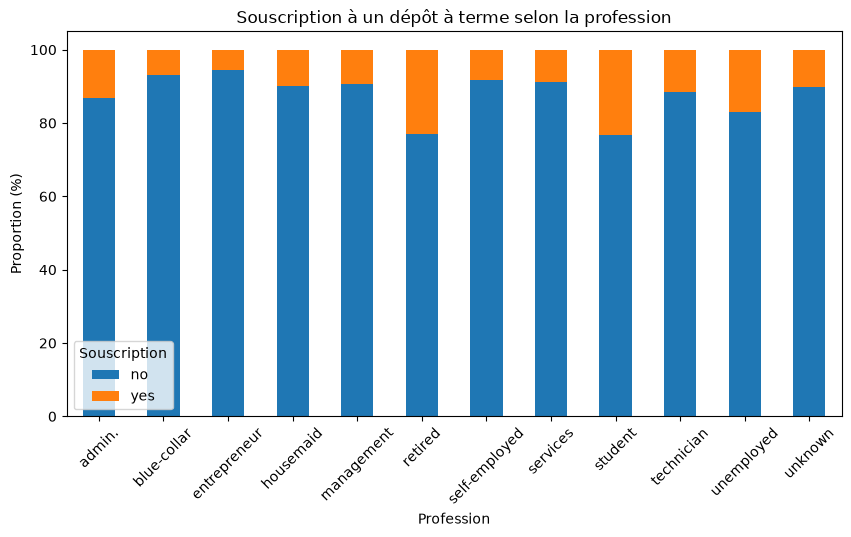

In [16]:
# Souscription selon la profession
#La proportion de souscription varie selon la profession, même si la réponse négative reste majoritaire dans toutes les catégories. Les personnes inactives et les chômeurs présentent une proportion de souscription relativement plus élevée, tandis que les travailleurs indépendants et les ouvriers semblent moins souvent répondre favorablement à l'offre.
job_y_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Souscription à un dépôt à terme selon la profession")
plt.xlabel("Profession")
plt.ylabel("Proportion (%)")
plt.legend(title="Souscription")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Création des classes d'âge
df["age_classe"] = pd.cut(
    df["age"],
    bins=[18, 30, 45, float("inf")],
    right=False,
    labels=["18-29 ans", "30-44 ans", "45 ans et plus"]
)

In [18]:
# Proportion de souscription selon la classe d'âge
age_y_pct = pd.crosstab(
    df["age_classe"],
    df["y"],
    normalize="index"
) * 100

age_y_pct

y,no,yes
age_classe,,
18-29 ans,87.840290,12.159710
30-44 ans,90.332594,9.667406
45 ans et plus,87.357197,12.642803


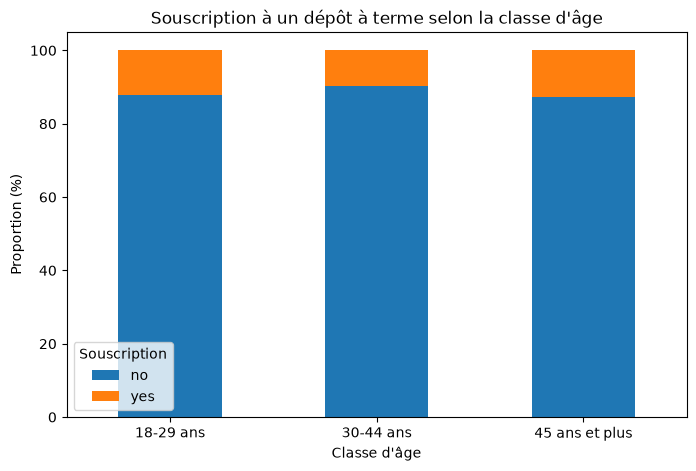

In [19]:
# Souscription selon la classe d'âge
age_y_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Souscription à un dépôt à terme selon la classe d'âge")
plt.xlabel("Classe d'âge")
plt.ylabel("Proportion (%)")
plt.legend(title="Souscription")
plt.xticks(rotation=0)
plt.show()

## 4. Analyse des variables numériques

Cette section vise à décrire les principales caractéristiques des variables numériques afin d'identifier leurs distributions, leurs dispersions et d'éventuelles valeurs extrêmes.

In [21]:
# Statistiques descriptives des variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.113620,10.313362,18.000,32.000,38.000,47.000,88.000
duration,4119.0,256.788055,254.703736,0.000,103.000,181.000,317.000,3643.000
campaign,4119.0,2.537266,2.568159,1.000,1.000,2.000,3.000,35.000
pdays,4119.0,960.422190,191.922786,0.000,999.000,999.000,999.000,999.000
previous,4119.0,0.190337,0.541788,0.000,0.000,0.000,0.000,6.000
emp.var.rate,4119.0,0.084972,1.563114,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,4119.0,93.579704,0.579349,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,4119.0,-40.499102,4.594578,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,4119.0,3.621356,1.733591,0.635,1.334,4.857,4.961,5.045
nr.employed,4119.0,5166.481695,73.667904,4963.600,5099.100,5191.000,5228.100,5228.100


**Observations :**

- **Âge (`age`) :** l'âge moyen des clients est d'environ 40 ans, avec une médiane de 38 ans. Les âges varient de 18 à 88 ans, ce qui indique une population d'âges relativement diversifiés.

- **Durée du dernier contact (`duration`) :** la durée moyenne est d'environ 257 secondes, contre une médiane de 181 secondes. Le maximum atteint 3 643 secondes, ce qui suggère une distribution asymétrique vers les valeurs élevées.

- **Nombre de contacts pendant la campagne (`campaign`) :** le nombre médian de contacts est de 2, et 75 % des clients ont été contactés au maximum 3 fois. Le maximum de 35 contacts révèle toutefois quelques valeurs élevées à examiner.

- **Jours depuis le dernier contact (`pdays`) :** la médiane et le troisième quartile sont égaux à 999. Cette valeur particulière semble correspondre à l'absence de contact lors d'une campagne précédente et devra être interprétée conformément à la documentation du jeu de données.

- **Contacts lors des campagnes précédentes (`previous`) :** au moins 75 % des observations présentent une valeur nulle. La majorité des clients ont donc eu peu ou pas de contacts lors des campagnes précédentes.

- **Indicateurs économiques :** les variables `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m` et `nr.employed` présentent des échelles et des dispersions différentes. Elles décrivent le contexte économique associé aux campagnes et pourront être examinées plus précisément lors de l'étude des relations entre variables.

## 5. Analyse des corrélations entre variables numériques

L'analyse des corrélations permet d'étudier les relations linéaires entre les variables numériques et d'identifier d'éventuelles redondances entre les variables explicatives.

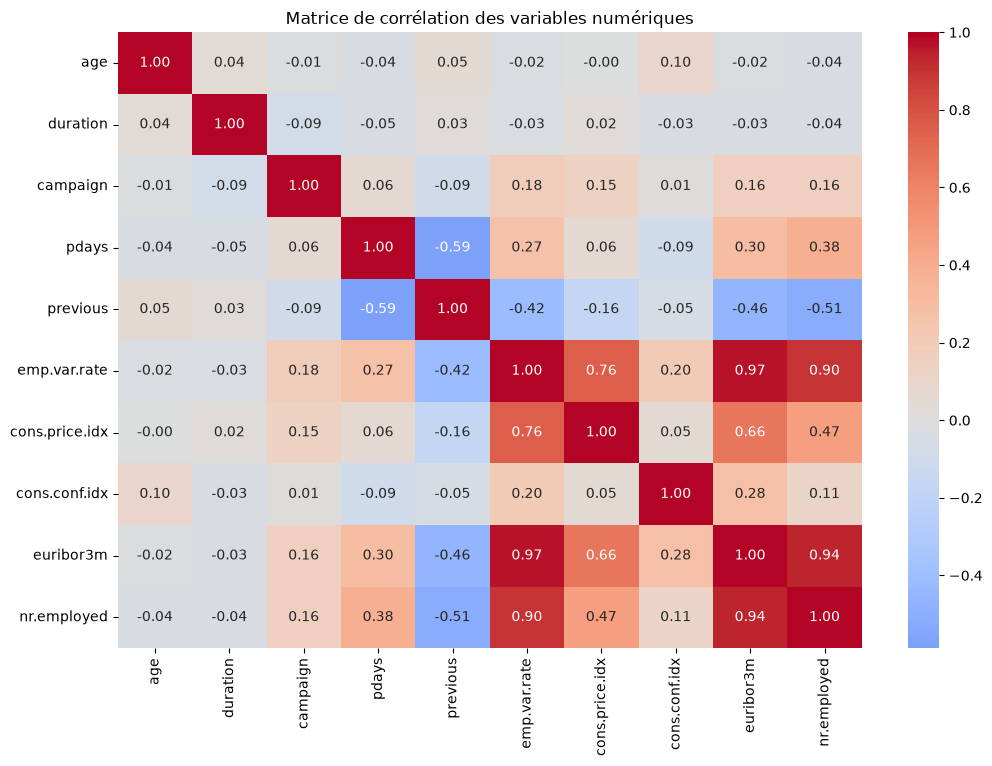

In [22]:
# Calcul de la matrice de corrélation
df_num = df.select_dtypes(include="number")

corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

**Observations :** Les corrélations les plus fortes concernent les variables économiques. `emp.var.rate` est fortement corrélée à `euribor3m` (0,97) et à `nr.employed` (0,90). Ces variables apportent donc des informations en partie similaires. On observe également une corrélation négative entre `pdays` et `previous` (-0,59), ainsi qu'entre `previous` et `nr.employed` (-0,51). Les autres variables présentent globalement des corrélations faibles entre elles.

### 5.1. Relation entre le résultat de la campagne précédente et la souscription

L'objectif est d'étudier si la proportion de clients ayant souscrit à l'offre (`y = yes`) varie selon le résultat de la campagne marketing précédente (`poutcome`). Cette analyse permettra d'examiner si l'historique des campagnes est associé à la souscription actuelle.

In [23]:
# Proportion de souscription selon le résultat de la campagne précédente
poutcome_y_pct = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

poutcome_y_pct

y,no,yes
poutcome,,
failure,85.242291,14.757709
nonexistent,91.711609,8.288391
success,35.211268,64.788732


## 7. Synthèse de l'analyse exploratoire

L'analyse exploratoire a permis de mieux comprendre la structure du jeu de données *Bank Marketing*, composé de 4 119 observations et de 21 variables. Elle a également mis en évidence plusieurs caractéristiques importantes pour la suite du projet.

Tout d'abord, la variable cible `y` présente un déséquilibre marqué : environ 89,1 % des clients n'ont pas souscrit à l'offre, contre 10,9 % ayant souscrit. Ce déséquilibre devra être pris en compte lors de la modélisation et dans le choix des indicateurs d'évaluation.

L'analyse de la qualité des données a révélé la présence de modalités `unknown`, particulièrement pour la variable `default`, qui représente environ 19,5 % des observations. Ces modalités devront faire l'objet d'un traitement réfléchi, en cohérence avec la méthodologie du projet de référence en R.

L'exploration des variables explicatives a également montré que la proportion de souscription varie selon certaines caractéristiques des clients et leur historique de contact. Ces premières observations permettront d'orienter les analyses ultérieures, sans suffire à établir des relations causales.

Enfin, l'étude des corrélations a mis en évidence des relations particulièrement fortes entre certaines variables économiques, notamment `emp.var.rate` et `euribor3m` (corrélation de 0,97). Ces relations devront être prises en compte lors de la préparation des données et de la modélisation.

**En conclusion**, cette première exploration fournit une base pour les étapes suivantes. Les résultats obtenus restent préliminaires : les décisions définitives concernant le nettoyage, le regroupement des modalités et la sélection des variables seront prises en suivant la méthodologie du projet R. L'objectif sera ensuite de construire un modèle capable de prédire la souscription à l'offre bancaire et d'évaluer rigoureusement ses performances.